In [4]:
import pandas as pd
import numpy as np

In [15]:
## Predict Tomorrow's Stock Price

In [12]:
df = pd.read_csv("prices-split-adjusted.csv")

In [13]:
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [21]:
df.shape


(851264, 7)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  str    
 1   symbol  851264 non-null  str    
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), str(2)
memory usage: 45.5 MB


In [22]:
df.dtypes

date          str
symbol        str
open      float64
close     float64
low       float64
high      float64
volume    float64
dtype: object

In [23]:
df.columns.tolist()

['date', 'symbol', 'open', 'close', 'low', 'high', 'volume']

In [26]:
df.describe()

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,64.993618,65.011913,64.336541,65.639748,5.415113e+06
std,75.203893,75.201216,74.459518,75.906861,1.249468e+07
min,1.660000,1.590000,1.500000,1.810000,0.000000e+00
25%,31.270000,31.292776,30.940001,31.620001,1.221500e+06
50%,48.459999,48.480000,47.970001,48.959999,2.476250e+06
75%,75.120003,75.139999,74.400002,75.849998,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [27]:
df.describe(include='all')

,date,symbol,open,close,low,high,volume
count,851264,851264,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
unique,1762,501,NaN,NaN,NaN,NaN,NaN
top,2016-07-05,A,NaN,NaN,NaN,NaN,NaN
freq,501,1762,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,64.993618,65.011913,64.336541,65.639748,5.415113e+06
std,NaN,NaN,75.203893,75.201216,74.459518,75.906861,1.249468e+07
min,NaN,NaN,1.660000,1.590000,1.500000,1.810000,0.000000e+00
25%,NaN,NaN,31.270000,31.292776,30.940001,31.620001,1.221500e+06
50%,NaN,NaN,48.459999,48.480000,47.970001,48.959999,2.476250e+06
75%,NaN,NaN,75.120003,75.139999,74.400002,75.849998,5.222500e+06


In [29]:
df.isnull().sum()

date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
print("Total Companies:", df['symbol'].nunique())

print("\nFirst 20 Stock Symbols:")
print(sorted(df['symbol'].unique())[:20])

Total Companies: 501

First 20 Stock Symbols:
['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN']


In [32]:
'AAPL' in df['symbol'].unique()

True

In [52]:
# Select input features
X = df[['open', 'high', 'low', 'close', 'volume']]

# Select target
y = df['Tomorrow_Close']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature Matrix Shape: (1761, 5)
Target Shape: (1761,)

Features:
        open       high        low      close       volume
0  30.490000  30.642857  30.340000  30.572857  123432400.0
1  30.657143  30.798571  30.464285  30.625713  150476200.0
2  30.625713  30.747143  30.107143  30.138571  138040000.0
3  30.250000  30.285715  29.864286  30.082857  119282800.0
4  30.042856  30.285715  29.865715  30.282858  111902700.0

Target:
0    30.625713
1    30.138571
2    30.082857
3    30.282858
4    30.015715
Name: Tomorrow_Close, dtype: float64


In [53]:
# Calculate the split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Split the features
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# Split the target
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (1408, 5)
Testing Set Shape: (353, 5)


In [54]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Learn scaling parameters from the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the testing data
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (1408, 5)
Testing Data Shape: (353, 5)


In [55]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [56]:
# Predict tomorrow's closing price
y_pred = lr_model.predict(X_test_scaled)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[115.59651069 119.79773939 113.61084016 115.11470574 115.15030075
 115.99495154 117.18189818 116.55628855 115.04062401 112.63041311]


In [57]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,119.720001,115.596511
1,113.489998,119.797739
2,115.239998,113.610840
3,115.150002,115.114706
4,115.959999,115.150301
5,117.160004,115.994952
6,116.500000,117.181898
7,115.010002,116.556289
8,112.650002,115.040624
9,105.760002,112.630413


In [58]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the results
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.2193
MSE  : 2.9518
RMSE : 1.7181
R²   : 0.9536


In [59]:
from sklearn.tree import DecisionTreeRegressor

# Create the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [60]:
# Predict on the test set
y_pred_dt = dt_model.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.8932
MSE  : 5.7982
RMSE : 2.4079
R²   : 0.9089


In [62]:
comparison_dt = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

comparison_dt.head(10)

,Actual,Predicted
0,119.720001,112.400002
1,113.489998,117.160004
2,115.239998,115.309998
3,115.150002,115.129997
4,115.959999,115.519997
5,117.160004,115.519997
6,116.500000,117.599998
7,115.010002,117.599998
8,112.650002,115.489998
9,105.760002,114.120003


In [63]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [64]:
y_pred_rf = rf_model.predict(X_test)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.4081
MSE  : 3.5918
RMSE : 1.8952
R²   : 0.9436


In [66]:
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

comparison_rf.head(10)

,Actual,Predicted
0,119.720001,113.989100
1,113.489998,118.521700
2,115.239998,114.452300
3,115.150002,114.788899
4,115.959999,115.325798
5,117.160004,115.851999
6,116.500000,117.121300
7,115.010002,117.259200
8,112.650002,115.410798
9,105.760002,112.247701


In [67]:
from sklearn.ensemble import GradientBoostingRegressor

# Create the model
gb_model = GradientBoostingRegressor(
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [68]:
y_pred_gb = gb_model.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_gb)
mse = mean_squared_error(y_test, y_pred_gb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_gb)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.4364
MSE  : 3.6481
RMSE : 1.9100
R²   : 0.9427


In [70]:
comparison_gb = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_gb
})

comparison_gb.head(10)

,Actual,Predicted
0,119.720001,115.450294
1,113.489998,119.023785
2,115.239998,114.702669
3,115.150002,114.474591
4,115.959999,115.543987
5,117.160004,115.387029
6,116.500000,117.598135
7,115.010002,117.659551
8,112.650002,114.942508
9,105.760002,112.314057


In [71]:
import pandas as pd

# Create a comparison table
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_gb)
    ]
})

# Calculate RMSE
results["RMSE"] = np.sqrt(results["MSE"])

# Calculate R²
results["R² Score"] = [
    r2_score(y_test, y_pred),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb)
]

# Round values for better readability
results = results.round(4)

results

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,1.2193,2.9518,1.7181,0.9536
1,Decision Tree,1.8932,5.7982,2.4079,0.9089
2,Random Forest,1.4081,3.5918,1.8952,0.9436
3,Gradient Boosting,1.4364,3.6481,1.9100,0.9427


In [73]:
from sklearn.model_selection import TimeSeriesSplit

# Create the Time Series Split object
tscv = TimeSeriesSplit(n_splits=5)

# Show each split
for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):
    print(f"Fold {fold}")
    print(f"Train Size: {len(train_index)}")
    print(f"Test Size : {len(test_index)}")
    print("-" * 30)

Fold 1
Train Size: 296
Test Size : 293
------------------------------
Fold 2
Train Size: 589
Test Size : 293
------------------------------
Fold 3
Train Size: 882
Test Size : 293
------------------------------
Fold 4
Train Size: 1175
Test Size : 293
------------------------------
Fold 5
Train Size: 1468
Test Size : 293
------------------------------


In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Build a pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# Metrics to calculate
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# Perform Cross Validation
scores = cross_validate(
    pipeline,
    X,
    y,
    cv=tscv,
    scoring=scoring
)

# Create summary table
cv_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Mean": [
        -scores["test_MAE"].mean(),
        -scores["test_RMSE"].mean(),
        scores["test_R2"].mean()
    ],
    "Standard Deviation": [
        scores["test_MAE"].std(),
        scores["test_RMSE"].std(),
        scores["test_R2"].std()
    ]
})

cv_results.round(4)

,Metric,Mean,Standard Deviation
0,MAE,1.0247,0.2235
1,RMSE,1.4178,0.2742
2,R²,0.9789,0.0124


In [75]:
from sklearn.metrics import r2_score
import pandas as pd

models = {
    "Linear Regression": (lr_model, X_train_scaled, X_test_scaled),
    "Decision Tree": (dt_model, X_train, X_test),
    "Random Forest": (rf_model, X_train, X_test),
    "Gradient Boosting": (gb_model, X_train, X_test)
}

results = []

for name, (model, Xtr, Xte) in models.items():
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    results.append({
        "Model": name,
        "Train R²": r2_score(y_train, train_pred),
        "Test R²": r2_score(y_test, test_pred)
    })

overfit_results = pd.DataFrame(results)
overfit_results = overfit_results.round(4)

overfit_results

,Model,Train R²,Test R²
0,Linear Regression,0.9980,0.9536
1,Decision Tree,1.0000,0.9089
2,Random Forest,0.9997,0.9436
3,Gradient Boosting,0.9988,0.9427


In [76]:
import pandas as pd

# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,close,0.445448
2,low,0.308496
1,high,0.141535
0,open,0.104111
4,volume,0.000409


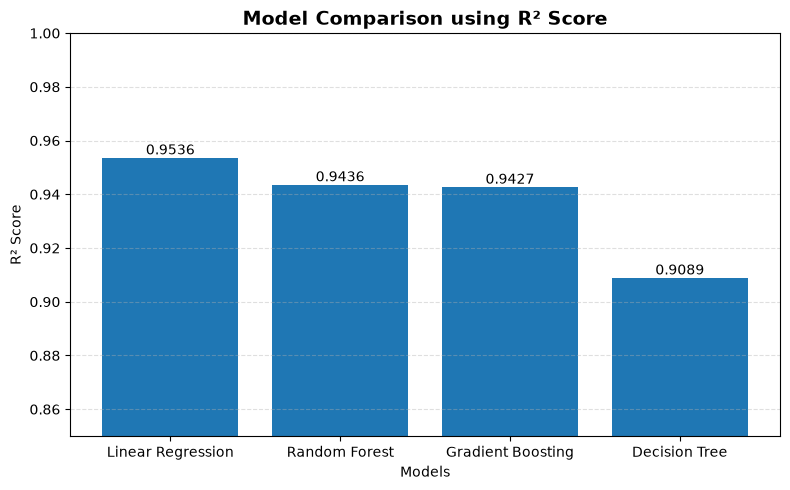

In [89]:
import matplotlib.pyplot as plt

# Sort by R² Score
plot_data = results.sort_values("R² Score", ascending=False)

plt.figure(figsize=(8,5))

bars = plt.bar(plot_data["Model"], plot_data["R² Score"])

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.4f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Model Comparison using R² Score", fontsize=14, fontweight="bold")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.ylim(0.85,1.0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

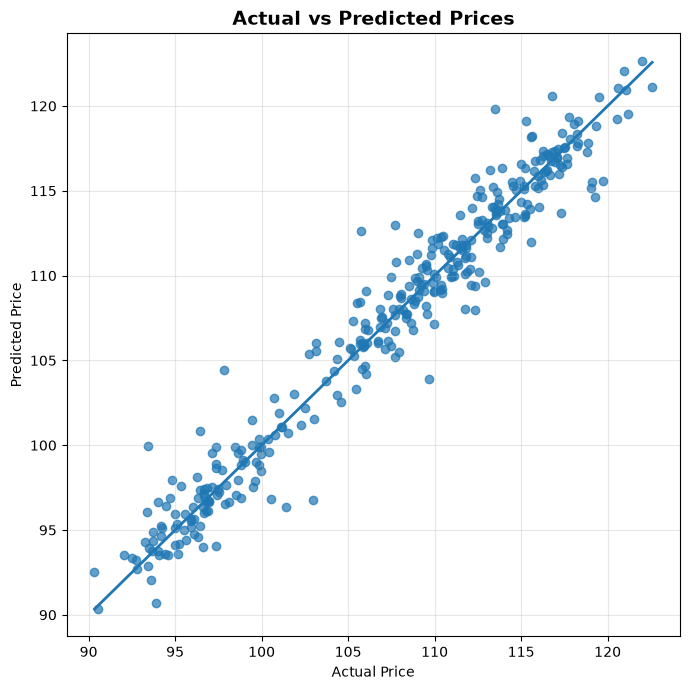

In [94]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.title("Actual vs Predicted Prices", fontsize=14, fontweight="bold")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

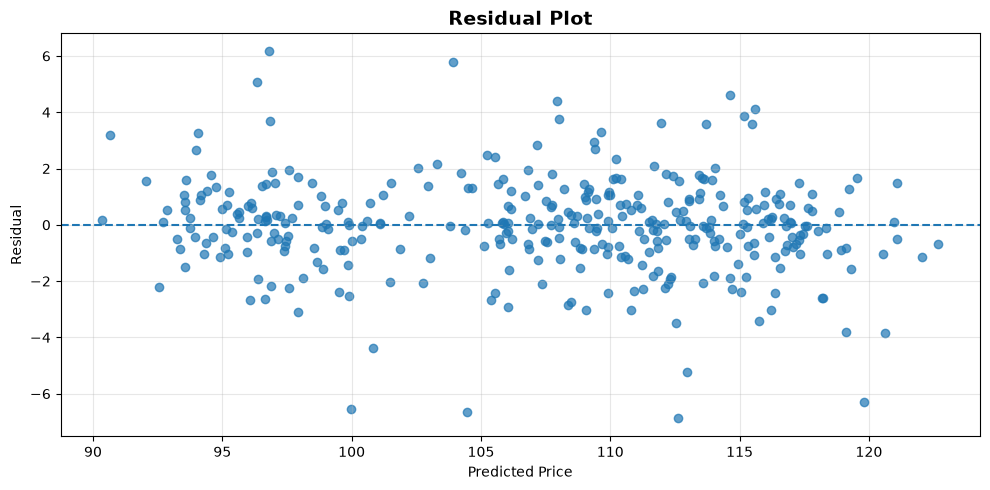

In [95]:
residuals = y_test - y_pred

plt.figure(figsize=(10,5))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

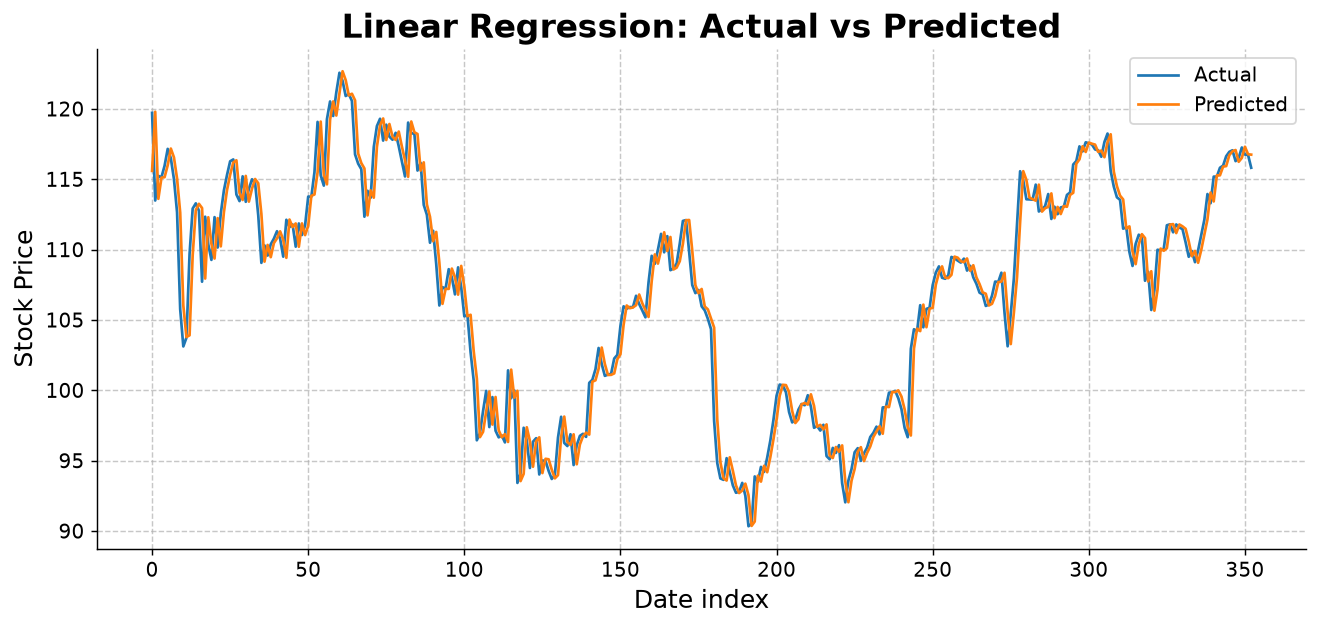

In [136]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Date index")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.7)

plt.show()

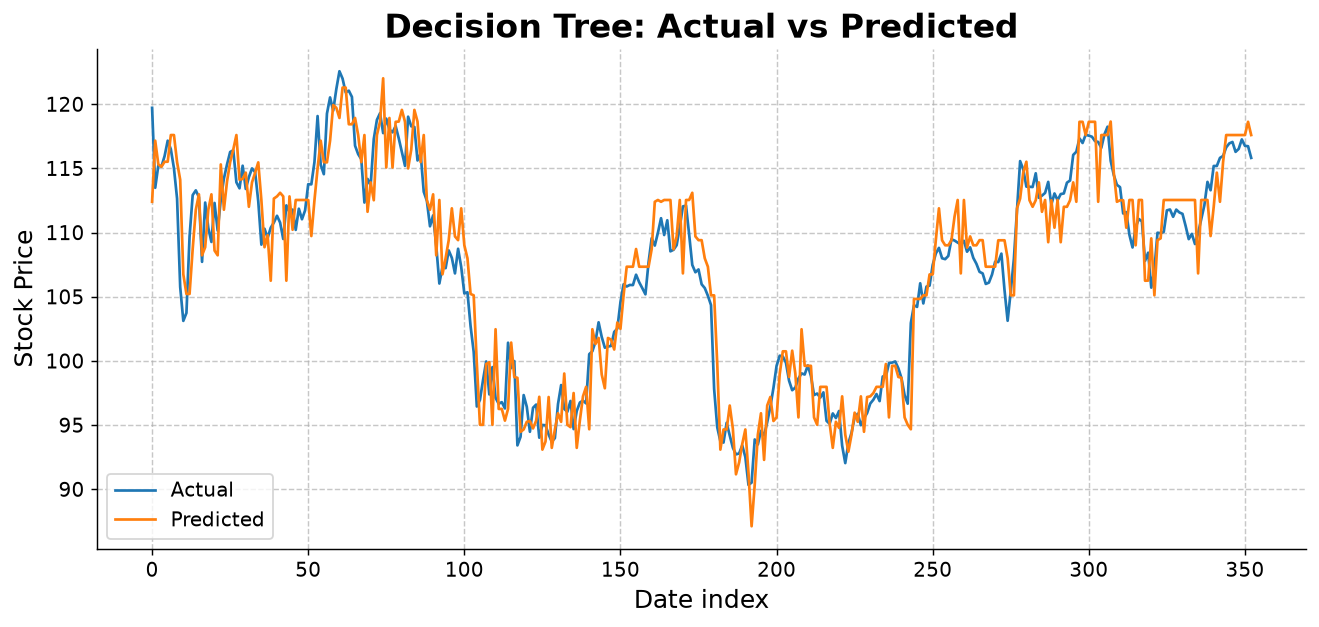

In [138]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_dt, label="Predicted")

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Date index")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.7)

plt.show()

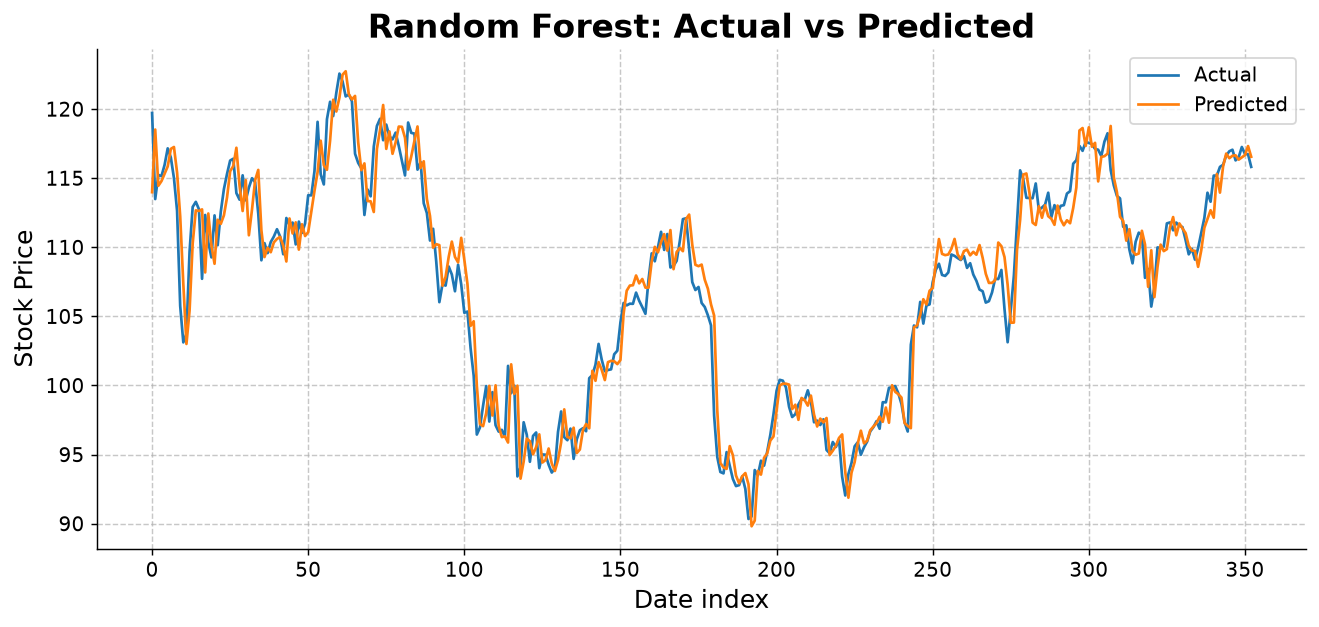

In [139]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Predicted")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Date index")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.7)

plt.show()

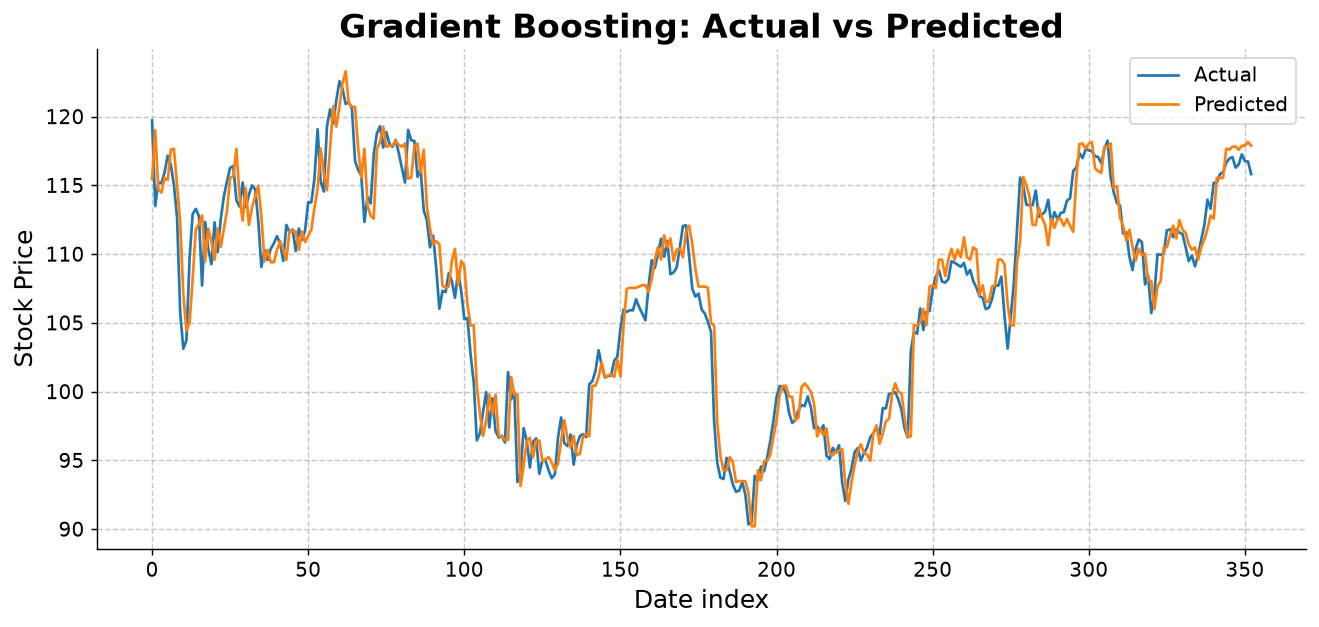

In [140]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_gb, label="Predicted")

plt.title("Gradient Boosting: Actual vs Predicted")
plt.xlabel("Date index")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.7)

plt.show()

In [109]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 120
})

In [110]:
colors = {
    "Linear Regression": "#1f77b4",   # Blue
    "Decision Tree": "#ff7f0e",       # Orange
    "Random Forest": "#2ca02c",       # Green
    "Gradient Boosting": "#d62728"    # Red
}

<Figure size 960x480 with 0 Axes>

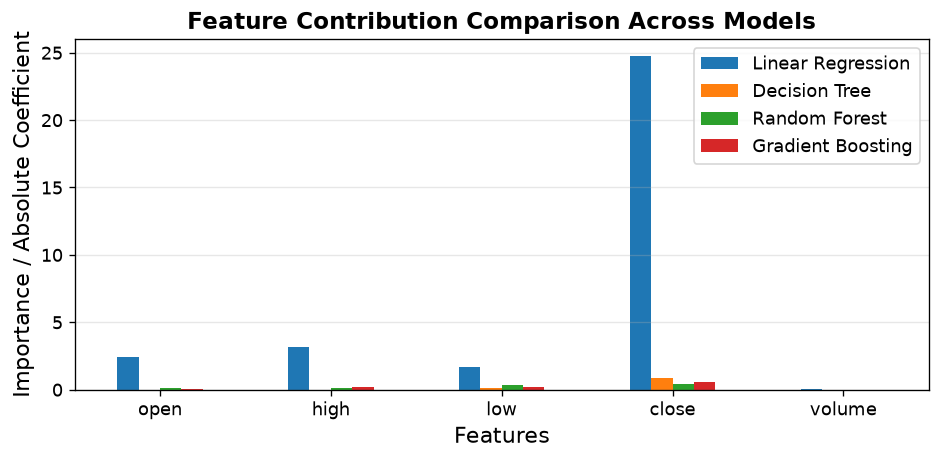

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": abs(lr_model.coef_),
    "Decision Tree": dt_model.feature_importances_,
    "Random Forest": rf_model.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_
})

importance_df = importance_df.set_index("Feature")

plt.figure(figsize=(8,4))

importance_df.plot(kind="bar", figsize=(8,4))

plt.title("Feature Contribution Comparison Across Models",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Features")
plt.ylabel("Importance / Absolute Coefficient")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

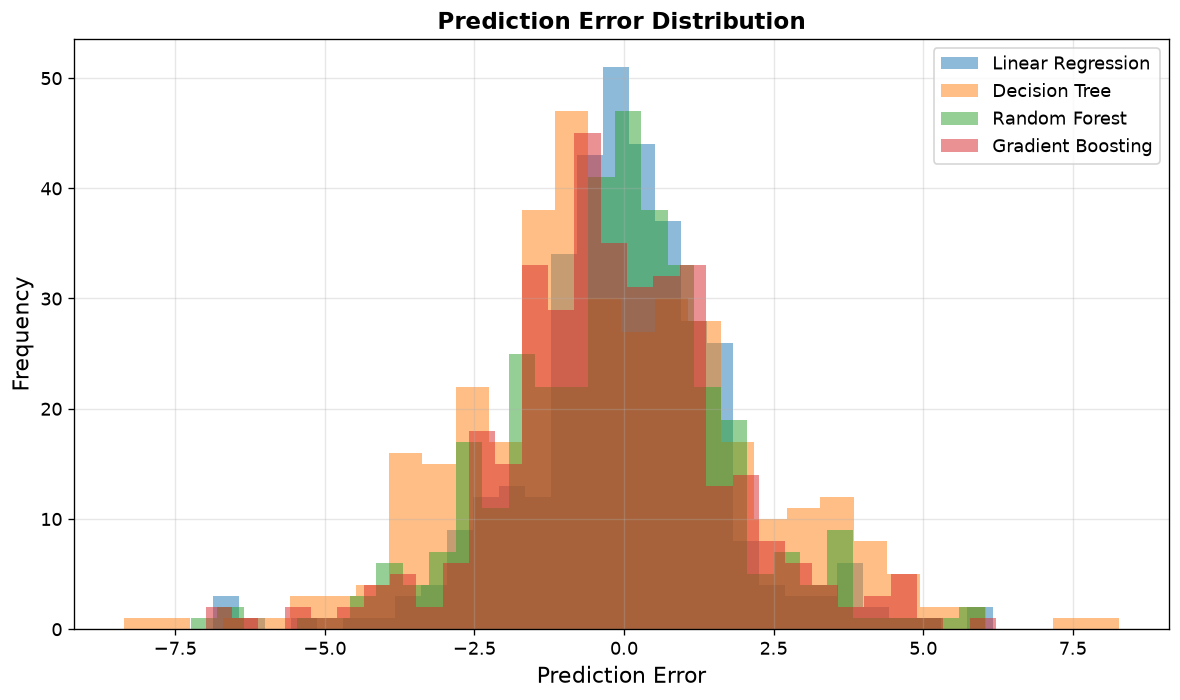

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(y_test - y_pred,
         bins=30,
         alpha=0.5,
         label="Linear Regression")

plt.hist(y_test - y_pred_dt,
         bins=30,
         alpha=0.5,
         label="Decision Tree")

plt.hist(y_test - y_pred_rf,
         bins=30,
         alpha=0.5,
         label="Random Forest")

plt.hist(y_test - y_pred_gb,
         bins=30,
         alpha=0.5,
         label="Gradient Boosting")

plt.title("Prediction Error Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

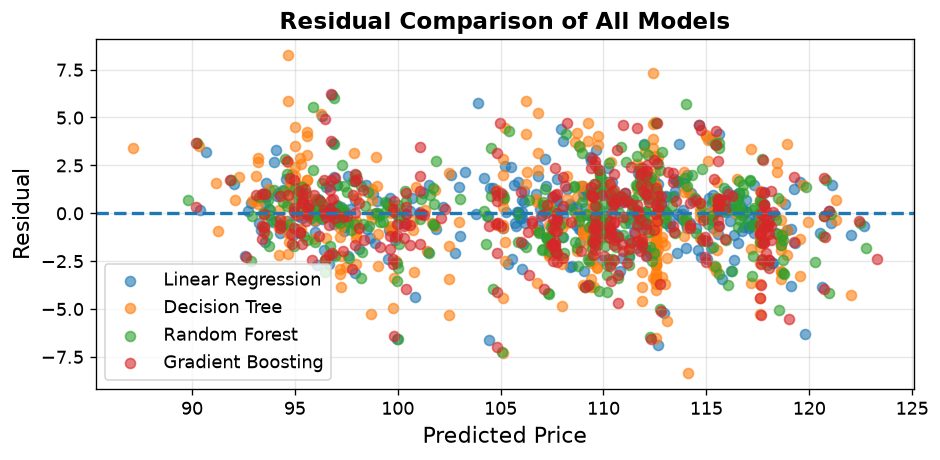

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.scatter(y_pred, y_test - y_pred,
            alpha=0.6, label="Linear Regression")

plt.scatter(y_pred_dt, y_test - y_pred_dt,
            alpha=0.6, label="Decision Tree")

plt.scatter(y_pred_rf, y_test - y_pred_rf,
            alpha=0.6, label="Random Forest")

plt.scatter(y_pred_gb, y_test - y_pred_gb,
            alpha=0.6, label="Gradient Boosting")

plt.axhline(y=0, linestyle="--", linewidth=2)

plt.title("Residual Comparison of All Models", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

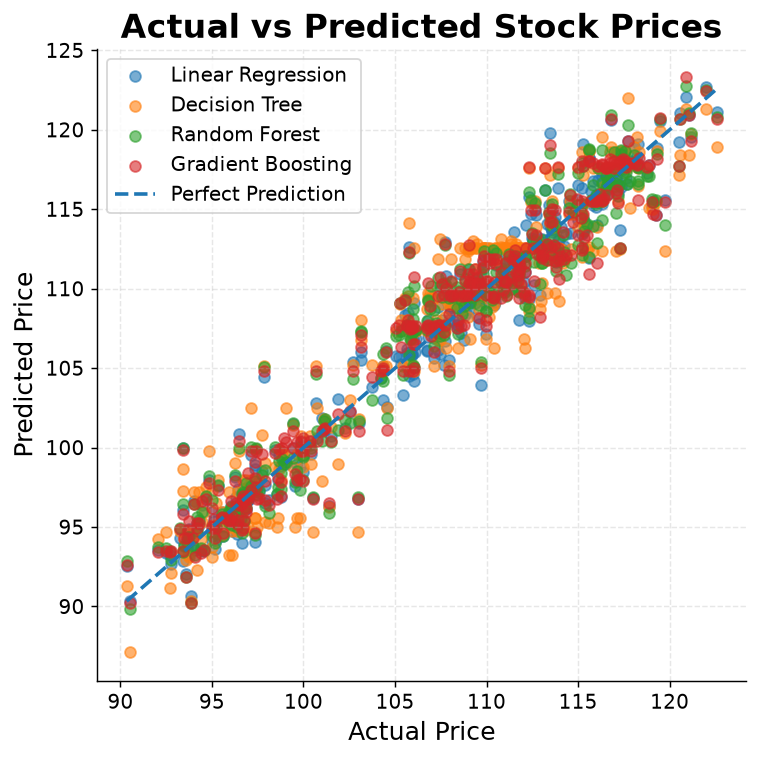

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Linear Regression
plt.scatter(y_test, y_pred, alpha=0.6, label="Linear Regression")

# Decision Tree
plt.scatter(y_test, y_pred_dt, alpha=0.6, label="Decision Tree")

# Random Forest
plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Random Forest")

# Gradient Boosting
plt.scatter(y_test, y_pred_gb, alpha=0.6, label="Gradient Boosting")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2,
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()